In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import lightgbm as lgb

e:\SIPaKMeD\sipakmed_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
csv_path = r"..\processed_data\extracted_features_enhanced.csv"
df = pd.read_csv(csv_path)

In [4]:
# Drop the Image_Name column and separate Features (X) from Target (y)
X = df.drop(columns=['Image_Name', 'True_Class'])
y = df['True_Class']

X.fillna(0, inplace=True)

In [5]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

In [6]:
print(f"Original Feature Count: {X_scaled.shape[1]}")

Original Feature Count: 51


In [7]:
base_lgb = lgb.LGBMClassifier(
    random_state=42, 
    n_estimators=300,
    colsample_bytree=0.2,
    verbose=-1
)
base_lgb.fit(X_scaled, y)


selector = SelectFromModel(base_lgb, prefit=True)
X_selected_array = selector.transform(X_scaled)
selected_feature_names = X_scaled.columns[selector.get_support()]
X_optimized = pd.DataFrame(X_selected_array, columns=selected_feature_names)

e:\SIPaKMeD\sipakmed_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [8]:
print(f"Reduced Feature Count after Selection: {X_optimized.shape[1]}")
print(f"\nFeatures Kept For Training:\n{list(selected_feature_names)}")

Reduced Feature Count after Selection: 20

Features Kept For Training:
['Cyt_Area', 'NC_Ratio', 'Chromatin_Variance', 'Nuc_Median', 'Nuc_Skew', 'Nucleus_Entropy', 'GLCM_Correlation', 'GLCM_Homogeneity', 'LBP_1', 'LBP_3', 'LBP_5', 'LBP_7', 'RG_Ratio', 'RB_Ratio', 'GB_Ratio', 'Prob_0', 'Prob_1', 'Prob_2', 'Prob_3', 'Prob_4']


In [9]:
# Split the optimized dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
                                        X_optimized, 
                                        y, 
                                        test_size=0.2, 
                                        random_state=42, 
                                        stratify=y
                                    )

In [10]:
# 1. Define settings to experiment with
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# 2. Setup the empty LightGBM model
lgb_tuner = lgb.LGBMClassifier(
    objective='multiclass', 
    num_class=5,
    verbose=-1
)

print("Testing EVERY single combination for LightGBM...")

# 3. Build the Automatic Tester (3-Fold Cross Validation)
grid_search = GridSearchCV(
    estimator=lgb_tuner, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=3, 
    verbose=1,
    n_jobs=-1  # Uses all your CPU cores!
)

# 4. Find the best model
grid_search.fit(X_train, y_train)

print(f"Best Settings Found: {grid_search.best_params_}")

# 5. Lock in the absolute best model
lgb_model = grid_search.best_estimator_


Testing EVERY single combination for LightGBM...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Settings Found: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}


In [11]:
predictions = lgb_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"LightGBM Meta-Learner Training Complete!")
print(f"FINAL ENSEMBLE ACCURACY: {accuracy * 100:.2f}%\n")

classes = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']
print("--- Detailed Classification Report ---")
print(classification_report(y_test, predictions, target_names=classes))


LightGBM Meta-Learner Training Complete!
FINAL ENSEMBLE ACCURACY: 98.64%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Dyskeratotic       0.99      0.99      0.99       163
Koilocytotic       0.99      0.98      0.98       165
 Metaplastic       0.98      0.97      0.97       159
   Parabasal       0.99      0.99      0.99       157
 Superficial       0.98      1.00      0.99       166

    accuracy                           0.99       810
   macro avg       0.99      0.99      0.99       810
weighted avg       0.99      0.99      0.99       810



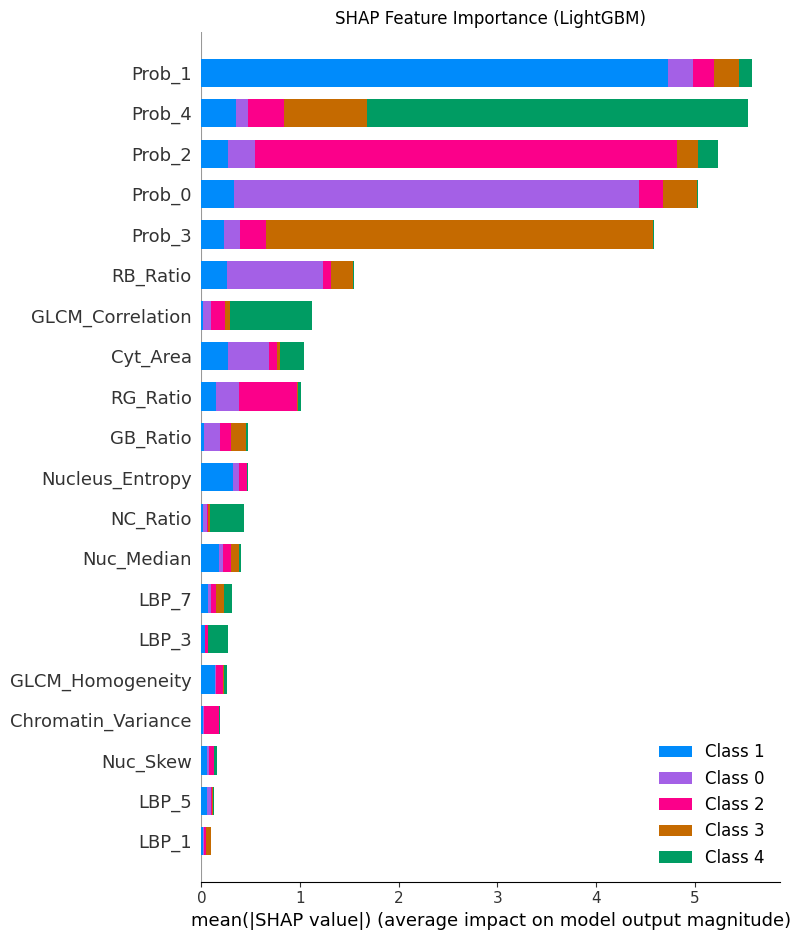


--- SHAP Impact on identifying Dyskeratotic Cells ---


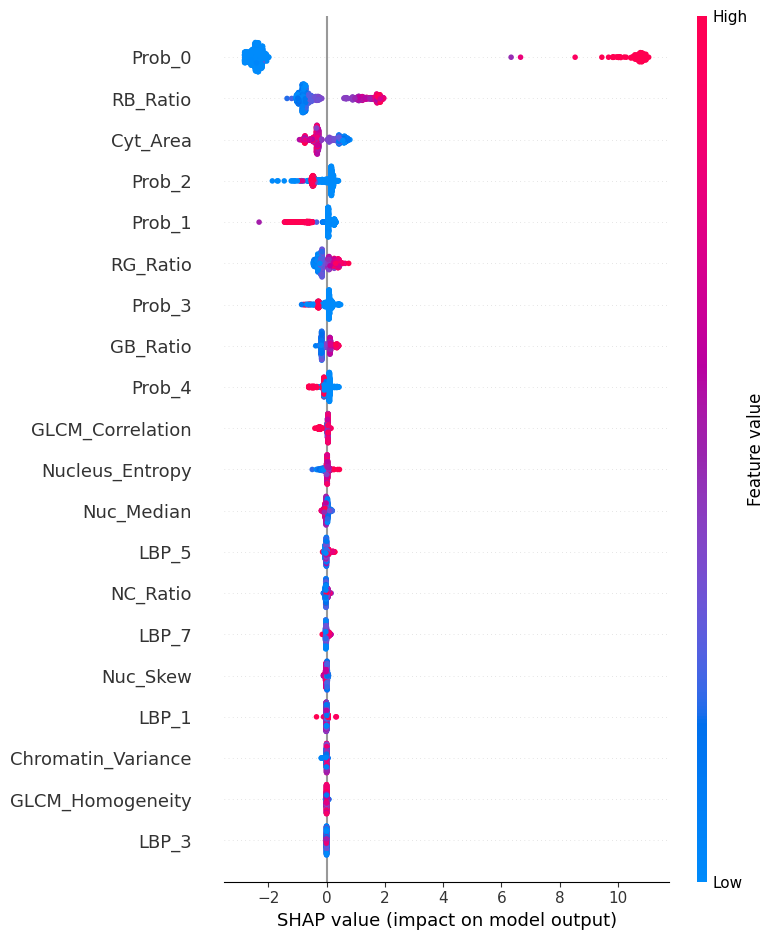

In [12]:
# Initialize SHAP (LightGBM loads flawlessly!)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# Graph 1: Overall Feature Importance
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance (LightGBM)")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Graph 2: Detailed Impact for Class 0 (Dyskeratotic)
print("\n--- SHAP Impact on identifying Dyskeratotic Cells ---")
plt.figure(figsize=(10, 6))

# Bulletproof check to slice Class 0 perfectly
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_vals_class0 = shap_values[:, :, 0]
else:
    shap_vals_class0 = shap_values[0]

shap.summary_plot(shap_vals_class0, X_test)

In [14]:
import os

os.makedirs(r"..\trained_models\meta_learners", exist_ok=True)
joblib.dump(lgb_model, r"..\trained_models\meta_learners\lightgbm_ensemble.pkl")
print("LightGBM Model Saved Successfully!")


LightGBM Model Saved Successfully!
